In [1]:
import os
import pandas as pd
import numpy as np


In [13]:
import os
import pandas as pd
import numpy as np


BASE_DIR = "/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Project"
OUTPUT_DIR = "/Users/haseebshafi/Documents/GitHub/Computational-Social-Science-2026/Final_project/Graph" 
YEARS = range(1988, 2008)  # 1988 to 2008 inclusive


def load_csv(filepath):
    df = pd.read_csv(filepath, low_memory=False, encoding="latin1")
    df = df.replace("NA", np.nan)
    return df


def clean_flight_data(df):
    df = df.copy()

    numeric_cols = [
        "AirTime",
        "ActualElapsedTime",
        "CRSElapsedTime",
        "ArrDelay",
        "DepDelay",
        "Distance",
        "Cancelled",
        "Diverted",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Distance" in df.columns:
        df["Distance_km"] = df["Distance"] * 1.60934
        df = df.drop(columns=["Distance"])
        df = df.rename(columns={"Distance_km": "Distance"})

    return df


def compute_yearly_stats(df, year):
    total_flights = len(df)
    cancelled = df["Cancelled"].sum() if "Cancelled" in df.columns else np.nan
    diverted = df["Diverted"].sum() if "Diverted" in df.columns else np.nan

    stats = {
        "year": year,
        "total_flights": total_flights,
        "cancelled_flights": int(cancelled) if not np.isnan(cancelled) else np.nan,
        "diverted_flights": int(diverted) if not np.isnan(diverted) else np.nan,
        "cancellation_rate_pct": round(cancelled / total_flights * 100, 4) if total_flights > 0 else np.nan,
        "avg_dep_delay_min": round(df["DepDelay"].mean(), 2) if "DepDelay" in df.columns else np.nan,
        "avg_arr_delay_min": round(df["ArrDelay"].mean(), 2) if "ArrDelay" in df.columns else np.nan,
        "avg_air_time_min": round(df["AirTime"].mean(), 2) if "AirTime" in df.columns else np.nan,
        "avg_actual_elapsed_time_min": round(df["ActualElapsedTime"].mean(), 2) if "ActualElapsedTime" in df.columns else np.nan,
        "avg_scheduled_elapsed_time_min": round(df["CRSElapsedTime"].mean(), 2) if "CRSElapsedTime" in df.columns else np.nan,
        "avg_distance_km": round(df["Distance"].mean(), 2) if "Distance" in df.columns else np.nan,
        "unique_origins": df["Origin"].nunique() if "Origin" in df.columns else np.nan,
        "unique_destinations": df["Dest"].nunique() if "Dest" in df.columns else np.nan,
        "unique_carriers": df["UniqueCarrier"].nunique() if "UniqueCarrier" in df.columns else np.nan,
        "pct_flights_delayed_dep": round((df["DepDelay"] > 0).sum() / total_flights * 100, 2) if "DepDelay" in df.columns else np.nan,
        "pct_flights_delayed_arr": round((df["ArrDelay"] > 0).sum() / total_flights * 100, 2) if "ArrDelay" in df.columns else np.nan,
    }

    return stats


def main():
    all_stats = []

    for year in YEARS:
        filepath = os.path.join(BASE_DIR, f"{year}.csv")

        if not os.path.exists(filepath):
            print(f"  [SKIP] {year}.csv not found, skipping.")
            continue

        print(f"Processing {year}...")
        df = load_csv(filepath)
        df = clean_flight_data(df)

        stats = compute_yearly_stats(df, year)
        all_stats.append(stats)

        print(f"  -> {stats['total_flights']:,} flights | "
              f"avg dep delay: {stats['avg_dep_delay_min']} min | "
              f"avg air time: {stats['avg_air_time_min']} min")

    summary_df = pd.DataFrame(all_stats)
    output_path = os.path.join(OUTPUT_DIR, "yearly_flight_stats_1988_2007.csv")
    summary_df.to_csv(output_path, index=False)
    print(f"\nSaved yearly stats to: {output_path}")
    print(summary_df.to_string(index=False))


if __name__ == "__main__":
    main()

Processing 1988...
  -> 5,202,096 flights | avg dep delay: 6.71 min | avg air time: nan min
Processing 1989...
  -> 5,041,200 flights | avg dep delay: 8.2 min | avg air time: nan min
Processing 1990...
  -> 5,270,893 flights | avg dep delay: 6.91 min | avg air time: nan min
Processing 1991...
  -> 5,076,925 flights | avg dep delay: 5.75 min | avg air time: nan min
Processing 1992...
  -> 5,092,157 flights | avg dep delay: 5.69 min | avg air time: nan min
Processing 1993...
  -> 5,070,501 flights | avg dep delay: 6.12 min | avg air time: nan min
Processing 1994...
  -> 5,180,048 flights | avg dep delay: 6.66 min | avg air time: nan min
Processing 1995...
  -> 5,327,435 flights | avg dep delay: 8.28 min | avg air time: 97.28 min
Processing 1996...
  -> 5,351,983 flights | avg dep delay: 9.99 min | avg air time: 99.71 min
Processing 1997...
  -> 5,411,843 flights | avg dep delay: 8.24 min | avg air time: 101.28 min
Processing 1998...
  -> 5,384,721 flights | avg dep delay: 9.02 min | avg 

In [19]:
import os
print(os.getcwd())
print(os.listdir())

/Users/haseebshafi/Documents/GitHub/Computational-Social-Science-2026/Final_project/Graph
['edges_2002_2003.csv', 'pictures', 'edges_1999_2000.csv', 'data_analysis_yearly.ipynb', 'yearly_flight_stats_1988_2007.csv', 'airport_node_analysis_2008.csv', 'Graph_analysis_1999-2003.ipynb', 'airport_nodes_2002_2003.csv', 'yearly_flight_stats_plot.png', 'airport_nodes_1999_2000.csv', 'yearly_flight_stats_combined.png']


Saved to: yearly_flight_stats_combined.png


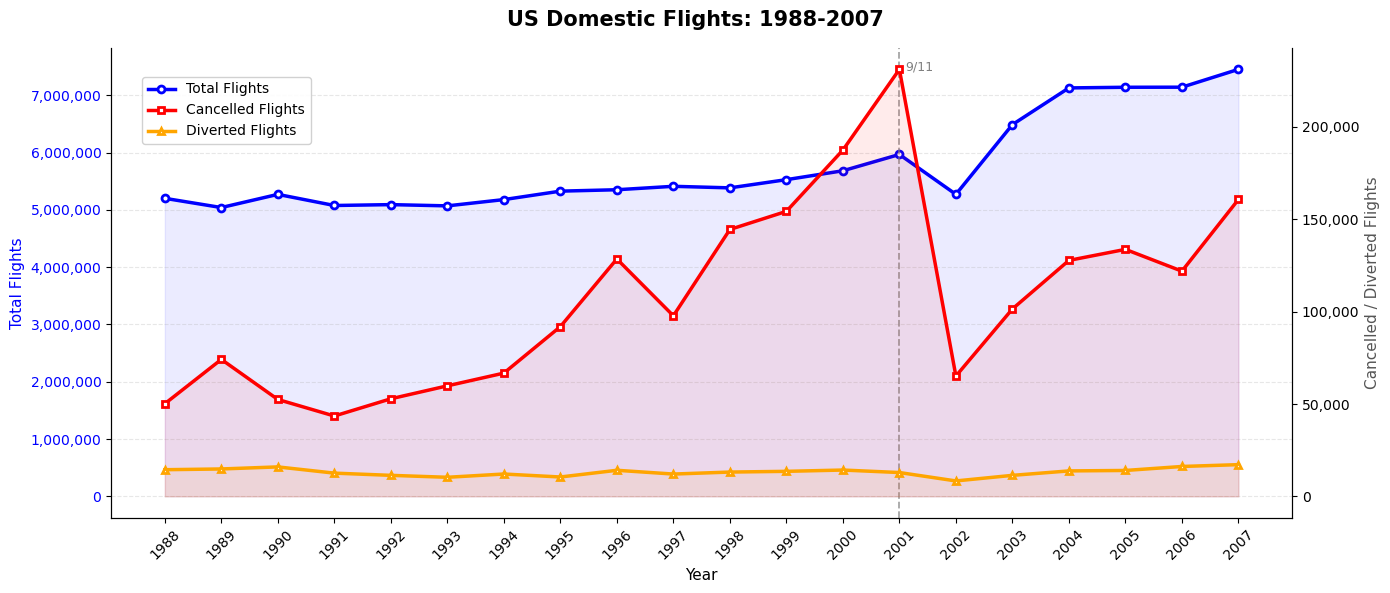

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

CSV_PATH = "yearly_flight_stats_1988_2007.csv"

df = pd.read_csv(CSV_PATH)
df = df.sort_values("year")

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# --- Left axis: total flights ---
l1, = ax1.plot(df["year"], df["total_flights"], color="blue", linewidth=2.5,
               marker="o", markersize=5, markerfacecolor="white", markeredgewidth=2,
               label="Total Flights")
ax1.fill_between(df["year"], df["total_flights"], alpha=0.08, color="blue")

# --- Right axis: cancelled & diverted ---
l2, = ax2.plot(df["year"], df["cancelled_flights"], color="red", linewidth=2.5,
               marker="s", markersize=5, markerfacecolor="white", markeredgewidth=2,
               label="Cancelled Flights")
ax2.fill_between(df["year"], df["cancelled_flights"], alpha=0.08, color="red")

l3, = ax2.plot(df["year"], df["diverted_flights"], color="orange", linewidth=2.5,
               marker="^", markersize=5, markerfacecolor="white", markeredgewidth=2,
               label="Diverted Flights")
ax2.fill_between(df["year"], df["diverted_flights"], alpha=0.08, color="orange")


ax1.axvline(x=2001, color="gray", linestyle="--", linewidth=1.3, alpha=0.7)
ax1.text(2001.1, ax1.get_ylim()[1] * 0.95, "9/11", color="gray", fontsize=9)

ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("Total Flights", fontsize=11, color="blue")
ax2.set_ylabel("Cancelled / Diverted Flights", fontsize=11, color="#555")

ax1.tick_params(axis="y", labelcolor="blue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax1.set_xticks(df["year"])
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)

fig.suptitle("US Domestic Flights: 1988-2007", fontsize=15, fontweight="bold")
fig.legend(handles=[l1, l2, l3], loc="upper left",
           bbox_to_anchor=(0.1, 0.88), framealpha=0.9, fontsize=10)

plt.tight_layout()
output_path = os.path.join(os.path.dirname(CSV_PATH), "yearly_flight_stats_combined.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved to: {output_path}")
plt.show()